In [1]:
from sklearn.pipeline import Pipeline as pl
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/ecoli/ecoli.data',
    sep = '\s+',
    header=None)
df.head()


<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_77600/3188946759.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  sep = '\s+',


,0,1,2,3,4,5,6,7,8
0,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,ADI_ECOLI,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp


In [3]:
x = df[df.columns.drop(8)]
y = df[8]


In [4]:
x.value_counts()

0           1     2     3     4    5     6     7   
AAS_ECOLI   0.44  0.52  0.48  0.5  0.43  0.47  0.54    1
PMBA_ECOLI  0.34  0.55  0.48  0.5  0.58  0.31  0.41    1
PPB_ECOLI   0.68  0.67  0.48  0.5  0.49  0.40  0.34    1
PPA_ECOLI   0.69  0.59  0.48  0.5  0.46  0.44  0.52    1
POTF_ECOLI  0.66  0.71  0.48  0.5  0.41  0.50  0.35    1
                                                      ..
FTSW_ECOLI  0.54  0.57  0.48  0.5  0.56  0.81  0.83    1
FTSQ_ECOLI  0.10  0.49  0.48  0.5  0.41  0.67  0.21    1
FTSN_ECOLI  0.00  0.51  0.48  0.5  0.35  0.67  0.44    1
FTSL_ECOLI  0.36  0.45  0.48  0.5  0.38  0.79  0.17    1
YTFQ_ECOLI  0.74  0.74  0.48  0.5  0.31  0.53  0.52    1
Name: count, Length: 336, dtype: int64

In [5]:
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.model_selection import train_test_split as tts


x[0] = LabelEncoder().fit_transform(np.ravel(x[0]))
y = LabelEncoder().fit_transform(np.ravel(y))


/tmp/ipykernel_77600/3942914328.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[0] = LabelEncoder().fit_transform(np.ravel(x[0]))


In [6]:
x

,0,1,2,3,4,5,6,7
0,1,0.49,0.29,0.48,0.5,0.56,0.24,0.35
1,2,0.07,0.40,0.48,0.5,0.54,0.35,0.44
2,3,0.56,0.40,0.48,0.5,0.49,0.37,0.46
3,4,0.59,0.49,0.48,0.5,0.52,0.45,0.36
4,5,0.23,0.32,0.48,0.5,0.55,0.25,0.35
...,...,...,...,...,...,...,...,...
331,318,0.74,0.56,0.48,0.5,0.47,0.68,0.30
332,323,0.71,0.57,0.48,0.5,0.48,0.35,0.32
333,326,0.61,0.60,0.48,0.5,0.44,0.39,0.38
334,333,0.59,0.61,0.48,0.5,0.42,0.42,0.37


In [7]:
xtrain , xtest , ytrain , ytest = tts(x,y,test_size=1/3,random_state=26,stratify=y)

In [8]:
from sklearn.neighbors import KNeighborsClassifier as knn
pll = pl([
    ("sc",StandardScaler()),
    ("kirkhar",knn())
])
from sklearn.pipeline import make_pipeline
pll = make_pipeline(StandardScaler(),knn())



In [9]:
pll.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](8,)","[0,1,2,...,5,6,7]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [10]:
pll.predict(np.array([12,325,345,45,7,5,6,7]).reshape(1,8))



array([5])

In [11]:
yhat = pll.predict(xtest)
from sklearn.metrics import classification_report as cr 
print(cr(ytest,yhat))
print(cr(ytrain,pll.predict(xtrain)))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94        48
           1       0.75      0.69      0.72        26
           3       0.00      0.00      0.00         1
           4       0.60      0.55      0.57        11
           5       1.00      0.71      0.83         7
           6       0.67      1.00      0.80         2
           7       0.89      0.94      0.91        17

    accuracy                           0.84       112
   macro avg       0.69      0.70      0.68       112
weighted avg       0.83      0.84      0.83       112

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        95
           1       0.85      0.88      0.87        51
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.79      0.62      0.70        24
           5       1.00      0.85      0.92        13
           6       0.43 

/usr/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/lib/python3.14/site-packages/sklearn/metrics/_clas

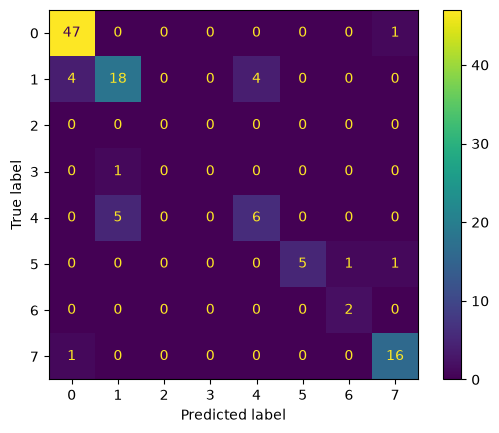

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay , confusion_matrix
cm =  confusion_matrix(ytest,yhat,labels=pll.classes_)
dis = ConfusionMatrixDisplay(cm,display_labels=pll.classes_)
dis.plot()

In [13]:
import joblib
joblib.dump(pll,"pipeline.joblib")

['pipeline.joblib']